
# NumPy Learning Notebook with a Simple Dataset

This notebook teaches the **core NumPy workflow** using a simple dataset.

What you'll learn:
- how to install and start Jupyter
- how to download/load a simple dataset
- how NumPy arrays work
- the most important NumPy functions and methods
- indexing, slicing, broadcasting, reshaping, math, statistics, sorting, and linear algebra
- how to use NumPy on a real dataset

**Dataset used:** Iris dataset  
It tries to download a CSV first, and if that fails, it falls back to the built-in scikit-learn copy.



## 1) Jupyter setup

Run these commands in Terminal:

```bash
pip install numpy pandas matplotlib scikit-learn jupyter
jupyter notebook
```

or, if you use conda:

```bash
conda install numpy pandas matplotlib scikit-learn jupyter
jupyter notebook
```

Then open this notebook and run cells from top to bottom.


In [ ]:

# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, precision=3)


ModuleNotFoundError: No module named 'Path'

## 2) Download or load a simple dataset

In [2]:

# Try downloading a CSV version of the Iris dataset.
# If the internet source is unavailable, fall back to scikit-learn's built-in dataset.

csv_url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"

try:
    iris_df = pd.read_csv(csv_url)
    source_used = "Downloaded from GitHub CSV"
except Exception as e:
    from sklearn.datasets import load_iris
    iris = load_iris(as_frame=True)
    iris_df = iris.frame.rename(columns={"target": "species_code"})
    iris_df["species"] = iris_df["species_code"].map(dict(enumerate(iris.target_names)))
    source_used = f"Fallback to scikit-learn built-in dataset because download failed: {e}"

print("Source:", source_used)
print()
print("Shape:", iris_df.shape)
iris_df.head()


Source: Downloaded from GitHub CSV

Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [6]:

# Save a local copy so you have a simple dataset file too
from pathlib import Path

Path("data").mkdir(exist_ok=True)
iris_df.to_csv("data/iris.csv", index=False)
print("Saved dataset to data/iris.csv")


Saved dataset to data/iris.csv



## 3) Convert dataset columns to NumPy arrays

NumPy works best with numeric arrays.


In [7]:

feature_cols = [col for col in iris_df.columns if col not in ["species", "species_code"]]
X = iris_df[feature_cols].to_numpy()
y = iris_df["species"].to_numpy()

print("Feature columns:", feature_cols)
print("X type:", type(X))
print("X shape:", X.shape)
print("y shape:", y.shape)
print()
print("First 5 rows of X:")
print(X[:5])
print()
print("First 5 labels:")
print(y[:5])


Feature columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
X type: <class 'numpy.ndarray'>
X shape: (150, 4)
y shape: (150,)

First 5 rows of X:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

First 5 labels:
['setosa' 'setosa' 'setosa' 'setosa' 'setosa']


## 4) Array creation functions

In [8]:

a = np.array([1, 2, 3, 4])
b = np.array([[1, 2, 3], [4, 5, 6]])

zeros = np.zeros((2, 3))
ones = np.ones((2, 3))
full = np.full((2, 3), 7)
eye = np.eye(3)
arange_arr = np.arange(0, 10, 2)
linspace_arr = np.linspace(0, 1, 5)
logspace_arr = np.logspace(1, 3, 4)
empty_arr = np.empty((2, 2))  # values are uninitialized

print("a:\n", a)
print("\nb:\n", b)
print("\nzeros:\n", zeros)
print("\nones:\n", ones)
print("\nfull:\n", full)
print("\neye:\n", eye)
print("\narange:", arange_arr)
print("linspace:", linspace_arr)
print("logspace:", logspace_arr)
print("empty:\n", empty_arr)


a:
 [1 2 3 4]

b:
 [[1 2 3]
 [4 5 6]]

zeros:
 [[0. 0. 0.]
 [0. 0. 0.]]

ones:
 [[1. 1. 1.]
 [1. 1. 1.]]

full:
 [[7 7 7]
 [7 7 7]]

eye:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

arange: [0 2 4 6 8]
linspace: [0.   0.25 0.5  0.75 1.  ]
logspace: [  10.      46.416  215.443 1000.   ]
empty:
 [[1.    1.667]
 [2.333 3.   ]]


## 5) Important array attributes and type conversion

In [9]:

arr = np.array([[1, 2, 3], [4, 5, 6]], dtype=np.float64)

print("arr:\n", arr)
print("ndim:", arr.ndim)
print("shape:", arr.shape)
print("size:", arr.size)
print("dtype:", arr.dtype)
print("itemsize:", arr.itemsize)
print("nbytes:", arr.nbytes)

arr_int = arr.astype(np.int32)
print("\nConverted dtype:")
print(arr_int)
print(arr_int.dtype)


arr:
 [[1. 2. 3.]
 [4. 5. 6.]]
ndim: 2
shape: (2, 3)
size: 6
dtype: float64
itemsize: 8
nbytes: 48

Converted dtype:
[[1 2 3]
 [4 5 6]]
int32


## 6) Random arrays

In [10]:

np.random.seed(42)

rand_uniform = np.random.rand(3, 3)
rand_ints = np.random.randint(0, 10, size=(3, 4))
normal_vals = np.random.normal(loc=0, scale=1, size=5)
choice_vals = np.random.choice([10, 20, 30, 40], size=6, replace=True)

print("np.random.rand:\n", rand_uniform)
print("\nnp.random.randint:\n", rand_ints)
print("\nnp.random.normal:\n", normal_vals)
print("\nnp.random.choice:\n", choice_vals)


np.random.rand:
 [[0.375 0.951 0.732]
 [0.599 0.156 0.156]
 [0.058 0.866 0.601]]

np.random.randint:
 [[7 2 5 4]
 [1 7 5 1]
 [4 0 9 5]]

np.random.normal:
 [-2.439  0.603 -0.251 -0.164 -1.476]

np.random.choice:
 [40 40 10 30 10 30]


## 7) Indexing and slicing

In [11]:

arr = np.arange(1, 13).reshape(3, 4)

print("arr:\n", arr)
print("\nFirst row:", arr[0])
print("Element at row 2, col 3:", arr[1, 2])
print("Last column:", arr[:, -1])
print("First two rows:\n", arr[:2])
print("Rows 1:3, Cols 1:3:\n", arr[1:3, 1:3])
print("Every other column:\n", arr[:, ::2])


arr:
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

First row: [1 2 3 4]
Element at row 2, col 3: 7
Last column: [ 4  8 12]
First two rows:
 [[1 2 3 4]
 [5 6 7 8]]
Rows 1:3, Cols 1:3:
 [[ 6  7]
 [10 11]]
Every other column:
 [[ 1  3]
 [ 5  7]
 [ 9 11]]


## 8) Boolean masks and fancy indexing

In [12]:

arr = np.array([5, 12, 7, 18, 3, 21])

mask = arr > 10
print("Array:", arr)
print("Mask:", mask)
print("Filtered:", arr[mask])

idx = [0, 2, 5]
print("Fancy indexing:", arr[idx])

# Dataset example: flowers with petal length > 5
petal_length = X[:, 2]
long_petals = X[petal_length > 5]
print("\nRows with petal length > 5:", long_petals.shape[0])
print(long_petals[:5])


Array: [ 5 12  7 18  3 21]
Mask: [False  True False  True False  True]
Filtered: [12 18 21]
Fancy indexing: [ 5  7 21]

Rows with petal length > 5: 42
[[6.  2.7 5.1 1.6]
 [6.3 3.3 6.  2.5]
 [5.8 2.7 5.1 1.9]
 [7.1 3.  5.9 2.1]
 [6.3 2.9 5.6 1.8]]


## 9) Reshape, flatten, ravel, transpose

In [13]:

arr = np.arange(12)

reshaped = arr.reshape(3, 4)
flattened = reshaped.flatten()   # copy
raveled = reshaped.ravel()       # view when possible
transposed = reshaped.T

print("Original:", arr)
print("\nReshaped:\n", reshaped)
print("\nFlattened:", flattened)
print("Raveled:", raveled)
print("\nTransposed:\n", transposed)


Original: [ 0  1  2  3  4  5  6  7  8  9 10 11]

Reshaped:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

Flattened: [ 0  1  2  3  4  5  6  7  8  9 10 11]
Raveled: [ 0  1  2  3  4  5  6  7  8  9 10 11]

Transposed:
 [[ 0  4  8]
 [ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]]


## 10) Concatenate and stack

In [14]:

a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6], [7, 8]])

print("concatenate axis=0:\n", np.concatenate([a, b], axis=0))
print("\nconcatenate axis=1:\n", np.concatenate([a, b], axis=1))
print("\nvstack:\n", np.vstack([a, b]))
print("\nhstack:\n", np.hstack([a, b]))
print("\nstack axis=0:\n", np.stack([a, b], axis=0))
print("\nstack axis=1:\n", np.stack([a, b], axis=1))


concatenate axis=0:
 [[1 2]
 [3 4]
 [5 6]
 [7 8]]

concatenate axis=1:
 [[1 2 5 6]
 [3 4 7 8]]

vstack:
 [[1 2]
 [3 4]
 [5 6]
 [7 8]]

hstack:
 [[1 2 5 6]
 [3 4 7 8]]

stack axis=0:
 [[[1 2]
  [3 4]]

 [[5 6]
  [7 8]]]

stack axis=1:
 [[[1 2]
  [5 6]]

 [[3 4]
  [7 8]]]


## 11) Split arrays

In [15]:

arr = np.arange(12)

print("array_split into 3 parts:")
parts = np.array_split(arr, 3)
for i, part in enumerate(parts, start=1):
    print(f"Part {i}:", part)


array_split into 3 parts:
Part 1: [0 1 2 3]
Part 2: [4 5 6 7]
Part 3: [ 8  9 10 11]


## 12) Arithmetic operations

In [16]:

a = np.array([1, 2, 3])
b = np.array([10, 20, 30])

print("a + b =", a + b)
print("a - b =", a - b)
print("a * b =", a * b)
print("b / a =", b / a)
print("a ** 2 =", a ** 2)


a + b = [11 22 33]
a - b = [ -9 -18 -27]
a * b = [10 40 90]
b / a = [10. 10. 10.]
a ** 2 = [1 4 9]


## 13) Broadcasting

In [17]:

matrix = np.array([[1, 2, 3], [4, 5, 6]])
vector = np.array([10, 20, 30])

print("Matrix:\n", matrix)
print("\nVector:", vector)
print("\nBroadcasted addition:\n", matrix + vector)

# Dataset example: subtract the column means from X
column_means = X.mean(axis=0)
centered_X = X - column_means

print("\nColumn means:", column_means)
print("First 5 centered rows:\n", centered_X[:5])


Matrix:
 [[1 2 3]
 [4 5 6]]

Vector: [10 20 30]

Broadcasted addition:
 [[11 22 33]
 [14 25 36]]

Column means: [5.843 3.057 3.758 1.199]
First 5 centered rows:
 [[-0.743  0.443 -2.358 -0.999]
 [-0.943 -0.057 -2.358 -0.999]
 [-1.143  0.143 -2.458 -0.999]
 [-1.243  0.043 -2.258 -0.999]
 [-0.843  0.543 -2.358 -0.999]]


## 14) Aggregation functions

In [18]:

arr = np.array([[1, 2, 3], [4, 5, 6]])

print("sum:", np.sum(arr))
print("sum axis=0:", np.sum(arr, axis=0))
print("sum axis=1:", np.sum(arr, axis=1))
print("mean:", np.mean(arr))
print("median:", np.median(arr))
print("std:", np.std(arr))
print("var:", np.var(arr))
print("min:", np.min(arr))
print("max:", np.max(arr))
print("argmin:", np.argmin(arr))
print("argmax:", np.argmax(arr))
print("percentile 25:", np.percentile(arr, 25))
print("quantile 0.75:", np.quantile(arr, 0.75))


sum: 21
sum axis=0: [5 7 9]
sum axis=1: [ 6 15]
mean: 3.5
median: 3.5
std: 1.707825127659933
var: 2.9166666666666665
min: 1
max: 6
argmin: 0
argmax: 5
percentile 25: 2.25
quantile 0.75: 4.75


## 15) Useful statistics on the Iris dataset

In [20]:

print("Column means:", np.mean(X, axis=0))
print("Column std:", np.std(X, axis=0))
print("Column min:", np.min(X, axis=0))
print("Column max:", np.max(X, axis=0))


Column means: [5.843 3.057 3.758 1.199]
Column std: [0.825 0.434 1.759 0.76 ]
Column min: [4.3 2.  1.  0.1]
Column max: [7.9 4.4 6.9 2.5]


## 16) Universal math functions (ufuncs)

In [19]:

arr = np.array([1, 4, 9, 16], dtype=float)

print("sqrt:", np.sqrt(arr))
print("exp:", np.exp([1, 2, 3]))
print("log:", np.log([1, np.e, np.e**2]))
print("sin:", np.sin([0, np.pi/2, np.pi]))
print("cos:", np.cos([0, np.pi/2, np.pi]))
print("abs:", np.abs([-3, -1, 0, 2]))
print("clip:", np.clip([-5, 0, 5, 10], 0, 6))
print("round:", np.round([1.234, 5.678], 2))
print("floor:", np.floor([1.9, 2.1, 3.7]))
print("ceil:", np.ceil([1.1, 2.1, 3.01]))


sqrt: [1. 2. 3. 4.]
exp: [ 2.718  7.389 20.086]
log: [0. 1. 2.]
sin: [0. 1. 0.]
cos: [ 1.  0. -1.]
abs: [3 1 0 2]
clip: [0 0 5 6]
round: [1.23 5.68]
floor: [1. 2. 3.]
ceil: [2. 3. 4.]


## 17) Sorting, searching, and set-like functions

In [21]:

arr = np.array([7, 2, 5, 2, 9, 1])

print("sort:", np.sort(arr))
print("argsort:", np.argsort(arr))
print("unique:", np.unique(arr))
print("bincount:", np.bincount(arr))
print("where > 4:", np.where(arr > 4))
print("searchsorted:", np.searchsorted(np.sort(arr), 5))
print("nonzero:", np.nonzero(arr))
print("any > 8:", np.any(arr > 8))
print("all > 0:", np.all(arr > 0))
print("isin [2, 9]:", np.isin(arr, [2, 9]))


sort: [1 2 2 5 7 9]
argsort: [5 1 3 2 0 4]
unique: [1 2 5 7 9]
bincount: [0 1 2 0 0 1 0 1 0 1]
where > 4: (array([0, 2, 4]),)
searchsorted: 3
nonzero: (array([0, 1, 2, 3, 4, 5]),)
any > 8: True
all > 0: True
isin [2, 9]: [False  True False  True  True False]


## 18) Linear algebra

In [22]:

A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])
v = np.array([1, 2])

print("dot:", np.dot(v, v))
print("\nmatmul A @ B:\n", A @ B)
print("\ntranspose of A:\n", A.T)
print("\ndeterminant of A:", np.linalg.det(A))
print("\ninverse of A:\n", np.linalg.inv(A))
print("\nnorm of v:", np.linalg.norm(v))

eigvals, eigvecs = np.linalg.eig(A)
print("\nEigenvalues:", eigvals)
print("Eigenvectors:\n", eigvecs)

solution = np.linalg.solve(A, np.array([5, 11]))
print("\nSolution to A x = [5, 11]:", solution)


dot: 5

matmul A @ B:
 [[19 22]
 [43 50]]

transpose of A:
 [[1 3]
 [2 4]]

determinant of A: -2.0000000000000004

inverse of A:
 [[-2.   1. ]
 [ 1.5 -0.5]]

norm of v: 2.23606797749979

Eigenvalues: [-0.372  5.372]
Eigenvectors:
 [[-0.825 -0.416]
 [ 0.566 -0.909]]

Solution to A x = [5, 11]: [1. 2.]


## 19) Copy vs view

In [23]:

arr = np.array([1, 2, 3, 4])
view_arr = arr[1:3]      # usually a view
copy_arr = arr.copy()    # explicit copy

view_arr[0] = 999
copy_arr[0] = -1

print("Original after editing view:", arr)
print("Copy after editing copy:", copy_arr)


Original after editing view: [  1 999   3   4]
Copy after editing copy: [-1  2  3  4]


## 20) Handling missing values

In [24]:

arr = np.array([1.0, np.nan, 3.0, np.nan, 5.0])

print("Original:", arr)
print("isnan:", np.isnan(arr))
print("nanmean:", np.nanmean(arr))
print("nansum:", np.nansum(arr))
print("Replace NaN with 0:", np.nan_to_num(arr, nan=0.0))


Original: [ 1. nan  3. nan  5.]
isnan: [False  True False  True False]
nanmean: 3.0
nansum: 9.0
Replace NaN with 0: [1. 0. 3. 0. 5.]


## 21) A practical mini workflow on the dataset

In [25]:

# Select only numeric features
X = iris_df[feature_cols].to_numpy()

# 1. Mean-center the data
means = X.mean(axis=0)
X_centered = X - means

# 2. Standardize the data
stds = X.std(axis=0)
X_standardized = (X - means) / stds

# 3. Filter rows
wide_sepal = X[X[:, 0] > 6.0]

print("Means:", means)
print("Standard deviations:", stds)
print("\nFirst 3 centered rows:\n", X_centered[:3])
print("\nFirst 3 standardized rows:\n", X_standardized[:3])
print("\nRows with sepal length > 6.0:", wide_sepal.shape[0])


Means: [5.843 3.057 3.758 1.199]
Standard deviations: [0.825 0.434 1.759 0.76 ]

First 3 centered rows:
 [[-0.743  0.443 -2.358 -0.999]
 [-0.943 -0.057 -2.358 -0.999]
 [-1.143  0.143 -2.458 -0.999]]

First 3 standardized rows:
 [[-0.901  1.019 -1.34  -1.315]
 [-1.143 -0.132 -1.34  -1.315]
 [-1.385  0.328 -1.397 -1.315]]

Rows with sepal length > 6.0: 61


## 22) Simple plotting with NumPy data

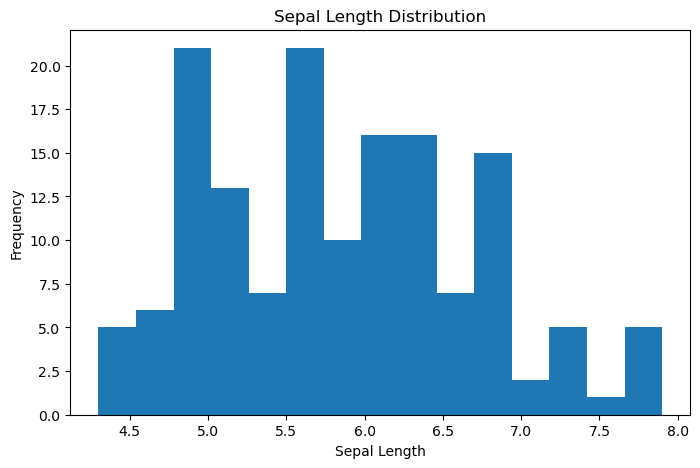

In [26]:

plt.figure(figsize=(8, 5))
plt.hist(X[:, 0], bins=15)
plt.title("Sepal Length Distribution")
plt.xlabel("Sepal Length")
plt.ylabel("Frequency")
plt.show()


## 23) Quick-reference: common NumPy functions by category

In [27]:

numpy_reference = {
    "Array creation": [
        "array", "asarray", "zeros", "ones", "empty", "full", "arange", "linspace",
        "logspace", "eye", "identity", "diag"
    ],
    "Shape manipulation": [
        "reshape", "ravel", "flatten", "transpose", "swapaxes", "squeeze", "expand_dims"
    ],
    "Combining/splitting": [
        "concatenate", "stack", "vstack", "hstack", "dstack", "split", "array_split"
    ],
    "Math": [
        "add", "subtract", "multiply", "divide", "power", "sqrt", "exp", "log",
        "sin", "cos", "tan", "abs", "clip", "round", "floor", "ceil"
    ],
    "Statistics": [
        "sum", "mean", "median", "std", "var", "min", "max", "argmin", "argmax",
        "percentile", "quantile"
    ],
    "Search/sort/set": [
        "sort", "argsort", "unique", "where", "searchsorted", "nonzero",
        "any", "all", "isin", "bincount"
    ],
    "Linear algebra": [
        "dot", "matmul", "linalg.det", "linalg.inv", "linalg.solve", "linalg.eig", "linalg.norm"
    ],
    "Random": [
        "random.seed", "random.rand", "random.randn", "random.randint",
        "random.choice", "random.normal", "random.uniform"
    ],
}

for category, funcs in numpy_reference.items():
    print(f"\n{category}:")
    print(", ".join(funcs))



Array creation:
array, asarray, zeros, ones, empty, full, arange, linspace, logspace, eye, identity, diag

Shape manipulation:
reshape, ravel, flatten, transpose, swapaxes, squeeze, expand_dims

Combining/splitting:
concatenate, stack, vstack, hstack, dstack, split, array_split

Math:
add, subtract, multiply, divide, power, sqrt, exp, log, sin, cos, tan, abs, clip, round, floor, ceil

Statistics:
sum, mean, median, std, var, min, max, argmin, argmax, percentile, quantile

Search/sort/set:
sort, argsort, unique, where, searchsorted, nonzero, any, all, isin, bincount

Linear algebra:
dot, matmul, linalg.det, linalg.inv, linalg.solve, linalg.eig, linalg.norm

Random:
random.seed, random.rand, random.randn, random.randint, random.choice, random.normal, random.uniform


## 24) Optional: inspect many public NumPy names

In [ ]:

public_numpy_names = [name for name in dir(np) if not name.startswith("_")]
print("Total public names in numpy:", len(public_numpy_names))
print(public_numpy_names[:200])  # show the first 200 alphabetically



## 25) Practice exercises

Try these on your own:

1. Create a 4x4 matrix of zeros, then change the diagonal to 1.
2. Create a NumPy array from 1 to 20 and reshape it into 4 rows and 5 columns.
3. From the Iris dataset, find all rows where petal width is greater than 2.0.
4. Compute the mean of each feature column.
5. Standardize the first feature column manually.
6. Sort the first feature column and return the original indices using `argsort`.
7. Compute the dot product of `[1, 2, 3]` and `[4, 5, 6]`.



## 26) Summary

You now have a working NumPy notebook that covers:
- creating arrays
- inspecting shapes and dtypes
- indexing and slicing
- broadcasting
- reshaping and stacking
- statistics and math
- sorting and searching
- linear algebra
- applying NumPy to a real dataset

A great next step is learning:
- pandas for tables
- matplotlib for plots
- scikit-learn for machine learning
